In [1]:
import os
import json
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import random
from datetime import datetime

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
from torch import manual_seed as torch_manual_seed
from torch.cuda import max_memory_allocated, set_device, manual_seed_all
from torch.backends import cudnn
import albumentations as A
from albumentations.pytorch import ToTensorV2
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA version:", torch.version.cuda)
print("CUDA device name:", torch.cuda.get_device_name(0))

PREVENT_TQDM = False # False if interactive
BATCH_SIZE = 12 # 12 if interactive
PRINT_EPOCH = 5
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

# if sbatch
if "80GB" in torch.cuda.get_device_name(0):
    BATCH_SIZE = 40
    PREVENT_TQDM = True
if "40GB" in torch.cuda.get_device_name(0):
    BATCH_SIZE = 32
    PREVENT_TQDM = True

Error importing huggingface_hub.hf_api: No module named 'h11'
Torch version: 2.11.0+cu130
CUDA available: True
Torch CUDA version: 13.0
CUDA device name: NVIDIA GeForce RTX 2080 Ti


In [2]:
class XView2Dataset(Dataset):
    def __init__(self, image_dir, label_dir, transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transform

        # anchor on post-disaster images
        self.files = sorted([
            f.replace("_post_disaster.jpg", "").replace("_post_disaster.png", "")
            for f in os.listdir(image_dir)
            if "_post_disaster" in f
        ])

        self.damage_map = {
            "no-damage": 1,
            "minor-damage": 2,
            "major-damage": 3,
            "destroyed": 4,
            "un-classified": 0   # sets building damage that was not classified to background which is not ideal but works for now
        }

    def __len__(self):
        return len(self.files)

    def _load_image(self, path):
        img = cv2.imread(path)

        # BGR → RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # normalize to [0,1]
        img = img.astype(np.float32) / 255.0

        return img

    def _load_post_mask(self, json_path, shape):
        H, W = shape
        mask = np.zeros((H, W), dtype=np.uint8)

        with open(json_path) as f:
            data = json.load(f)

        for feature in data["features"]["xy"]:
            props = feature["properties"]

            if "subtype" not in props:
                continue

            damage = props["subtype"]
            class_id = self.damage_map[damage]

            wkt = feature["wkt"]
            coords = wkt.replace("POLYGON ((", "").replace("))", "")

            points = []
            for pair in coords.split(","):
                x, y = map(float, pair.strip().split())
                points.append([int(x), int(y)])

            pts = np.array(points, dtype=np.int32)
            cv2.fillPoly(mask, [pts], class_id)

        return mask

    def _load_pre_mask(self, json_path, shape):
        H, W = shape
        mask = np.zeros((H, W), dtype=np.uint8)

        with open(json_path) as f:
            data = json.load(f)

        for feature in data["features"]["xy"]:
            wkt = feature["wkt"]
            coords = wkt.replace("POLYGON ((", "").replace("))", "")

            points = []
            for pair in coords.split(","):
                x, y = map(float, pair.strip().split())
                points.append([int(x), int(y)])

            pts = np.array(points, dtype=np.int32)
            cv2.fillPoly(mask, [pts], 1)  # binary mask

        return mask

    def __getitem__(self, idx):
        base = self.files[idx]

        # handle jpg or png automatically
        for ext in [".jpg", ".png"]:
            pre_path = os.path.join(self.image_dir, base + "_pre_disaster" + ext)
            post_path = os.path.join(self.image_dir, base + "_post_disaster" + ext)
            if os.path.exists(pre_path):
                break

        # load iamges
        pre_img = self._load_image(pre_path)
        post_img = self._load_image(post_path)

        # load masks
        pre_label_path = os.path.join(self.label_dir, base + "_pre_disaster.json")
        post_label_path = os.path.join(self.label_dir, base + "_post_disaster.json")

        pre_mask = self._load_pre_mask(pre_label_path, pre_img.shape[:2])
        post_mask = self._load_post_mask(post_label_path, pre_img.shape[:2])

        # APPLY AUGMENTATION
        if self.transform:
            augmented = self.transform(
                image=pre_img,
                image_post=post_img,
                pre_mask=pre_mask,
                post_mask=post_mask
            )

            pre_img = augmented["image"]
            post_img = augmented["image_post"]
            pre_mask = augmented["pre_mask"]
            post_mask = augmented["post_mask"]

        # stack images → 6 channels; convert to tensors
        image = np.concatenate([pre_img, post_img], axis=2)
        image = torch.tensor(image).permute(2, 0, 1).float()

        return {
            "image": image,
            "pre_mask": torch.tensor(pre_mask).long(),
            "post_mask": torch.tensor(post_mask).long()
        }

In [3]:
def visualize_full(sample):
    img = sample["image"]
    pre_mask = sample["pre_mask"].numpy()
    post_mask = sample["post_mask"].numpy()

    pre = img[:3].permute(1,2,0).numpy()
    post = img[3:].permute(1,2,0).numpy()

    cmap = plt.get_cmap("jet", 5)

    fig, axes = plt.subplots(2, 3, figsize=(14, 11))

    # --- PRE ---
    axes[0,0].imshow(pre)
    axes[0,0].set_title("Pre Image")
    axes[0,0].axis("off")

    axes[0,1].imshow(pre)
    axes[0,1].imshow(pre_mask, cmap="gray", alpha=0.5)
    axes[0,1].set_title("Pre + Building Mask")
    axes[0,1].axis("off")

    axes[0,2].imshow(pre_mask, cmap="gray")
    axes[0,2].set_title("Pre Mask Only")
    axes[0,2].axis("off")

    # --- POST ---
    axes[1,0].imshow(post)
    axes[1,0].set_title("Post Image")
    axes[1,0].axis("off")

    axes[1,1].imshow(post)
    axes[1,1].imshow(post_mask, cmap=cmap, alpha=0.5, vmin=0, vmax=4)
    axes[1,1].set_title("Post + Damage Mask")
    axes[1,1].axis("off")

    axes[1,2].imshow(post_mask, cmap=cmap, vmin=0, vmax=4)
    axes[1,2].set_title("Post Mask Only")
    axes[1,2].axis("off")

    # # --- COMPARISON ---
    # axes[2,0].imshow(pre_mask, cmap="gray")
    # axes[2,0].set_title("Buildings")
    # axes[2,0].axis("off")

    # axes[2,1].imshow(post_mask, cmap=cmap, vmin=0, vmax=4)
    # axes[2,1].set_title("Damage Classes")
    # axes[2,1].axis("off")

    # axes[2,2].imshow(pre)
    # axes[2,2].imshow(post_mask, cmap=cmap, alpha=0.5)
    # axes[2,2].set_title("Damage Overlay")
    # axes[2,2].axis("off")

    # --- LEGEND ---
    class_names = [
        "Background",
        "No Damage",
        "Minor Damage",
        "Major Damage",
        "Destroyed"
    ]

    colors = [cmap(i) for i in range(5)]
    patches = [mpatches.Patch(color=colors[i], label=class_names[i]) for i in range(5)]

    fig.legend(
        handles=patches,
        loc="lower center",
        ncol=5,
        bbox_to_anchor=(0.5, 0.02)
    )

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

def visualize_aug(sample, transform):
    pre = sample["image"][:3].permute(1,2,0).numpy()
    post = sample["image"][3:].permute(1,2,0).numpy()

    pre_mask = sample["pre_mask"].numpy()
    post_mask = sample["post_mask"].numpy()

    aug = transform(
        image=pre,
        image_post=post,
        pre_mask=pre_mask,
        post_mask=post_mask
    )

    aug_image = np.concatenate([aug["image"], aug["image_post"]], axis=2)

    visualize_full({
        "image": torch.tensor(aug_image).permute(2,0,1),
        "pre_mask": torch.tensor(aug["pre_mask"]),
        "post_mask": torch.tensor(aug["post_mask"])
    })

In [4]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class UNetDualHead(nn.Module):
    def __init__(self, in_channels=6):
        super().__init__()

        # Layer feature sizes
        f1 = 32
        f2 = 64
        f3 = 128
        f4 = 256
        f5 = 512

        # Encoder
        self.enc1 = DoubleConv(in_channels, f1)
        self.enc2 = DoubleConv(f1, f2)
        self.enc3 = DoubleConv(f2, f3)
        self.enc4 = DoubleConv(f3, f4)

        # Pooling
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(f4, f5)

        # Decoder
        self.up4 = nn.ConvTranspose2d(f5, f4, 2, stride=2)
        self.dec4 = DoubleConv(f5, f4)

        self.up3 = nn.ConvTranspose2d(f4, f3, 2, stride=2)
        self.dec3 = DoubleConv(f4, f3)

        self.up2 = nn.ConvTranspose2d(f3, f2, 2, stride=2)
        self.dec2 = DoubleConv(f3, f2)

        self.up1 = nn.ConvTranspose2d(f2, f1, 2, stride=2)
        self.dec1 = DoubleConv(f2, f1)

        # final shared features
        self.final_features = nn.Conv2d(f1, f1, kernel_size=1)

        # TWO HEADS
        self.building_head = nn.Conv2d(f1, 1, kernel_size=1)
        self.damage_head = nn.Conv2d(f1, 5, kernel_size=1)

    def forward(self, x):
        # encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # bottleneck
        b = self.bottleneck(self.pool(e4))

        # decoder
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        features = self.final_features(d1)

        building_out = self.building_head(features)
        damage_out = self.damage_head(features)

        return building_out, damage_out
    
    def _get_param_lists(self):
        backbone_params = []
        building_head_params = []
        damage_head_params = []

        for name, param in self.named_parameters():
            if 'building_head' in name:
                building_head_params.append(param)
            elif 'damage_head' in name:
                damage_head_params.append(param)
            else:
                backbone_params.append(param)
        
        return backbone_params, building_head_params, damage_head_params

device_name = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device(device_name)
scaler = torch.amp.GradScaler('cuda')
model = UNetDualHead(in_channels=6).to(device_name)
state_dict = torch.load("sbatch_output/model_weights--20260405_025702.pth")
# state_dict = torch.load("sbatch_output/model_weights--20260405_184655.pth")
model.load_state_dict(state_dict)

<All keys matched successfully>

In [5]:
def get_predictions(building_out, damage_out, threshold=0.5):
    # building
    building_prob = torch.sigmoid(building_out)
    building_mask = (building_prob > threshold).long()

    # damage
    damage_prob = torch.softmax(damage_out, dim=1)
    damage_pred = torch.argmax(damage_prob, dim=1)

    # apply mask
    final_damage = damage_pred * building_mask.squeeze(1)

    return building_mask.squeeze(1), final_damage

In [6]:
def visualize_prediction(sample, pred_mask):
    """
    sample: dict from dataset
    pred_mask: (H, W) tensor or numpy array
    """

    # --- Extract data ---
    img = sample["image"]
    gt_mask = sample["post_mask"]

    # convert to numpy
    post_img = img[3:].permute(1,2,0).cpu().numpy()
    gt_mask = gt_mask.cpu().numpy()

    if torch.is_tensor(pred_mask):
        pred_mask = pred_mask.cpu().numpy()

    # --- colormap ---
    cmap = plt.get_cmap("jet", 5)

    # --- figure ---
    fig, axes = plt.subplots(2, 3, figsize=(14, 10))

    # =========================
    # Ground Truth (top row)
    # =========================

    # post image
    axes[0,0].imshow(post_img)
    axes[0,0].set_title("GT Post Image")
    axes[0,0].axis("off")

    # overlay
    axes[0,1].imshow(post_img)
    axes[0,1].imshow(gt_mask, cmap=cmap, alpha=0.5, vmin=0, vmax=4)
    axes[0,1].set_title("GT Overlay")
    axes[0,1].axis("off")

    # mask only
    axes[0,2].imshow(gt_mask, cmap=cmap, vmin=0, vmax=4)
    axes[0,2].set_title("GT Mask")
    axes[0,2].axis("off")

    # =========================
    # Prediction (bottom row)
    # =========================

    # post image
    axes[1,0].imshow(post_img)
    axes[1,0].set_title("Pred Post Image")
    axes[1,0].axis("off")

    # overlay
    axes[1,1].imshow(post_img)
    axes[1,1].imshow(pred_mask, cmap=cmap, alpha=0.5, vmin=0, vmax=4)
    axes[1,1].set_title("Pred Overlay")
    axes[1,1].axis("off")

    # mask only
    axes[1,2].imshow(pred_mask, cmap=cmap, vmin=0, vmax=4)
    axes[1,2].set_title("Pred Mask")
    axes[1,2].axis("off")

    # =========================
    # Legend
    # =========================
    class_names = [
        "Background",
        "No Damage",
        "Minor Damage",
        "Major Damage",
        "Destroyed"
    ]

    colors = [cmap(i) for i in range(5)]
    patches = [mpatches.Patch(color=colors[i], label=class_names[i]) for i in range(5)]

    fig.legend(
        handles=patches,
        loc="lower center",
        ncol=5,
        bbox_to_anchor=(0.5, 0.02)
    )

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

In [7]:
base_folder = "content/data/xview2_jpeg"
subfolder = "hold"
dataset = XView2Dataset(f"{base_folder}/{subfolder}/images_jpeg", f"{base_folder}/{subfolder}/labels")

In [8]:
sample = dataset[3]
# visualize_full(sample)
cuda_image = sample["image"].unsqueeze(0).to(device, non_blocking=True)

model.eval()
with torch.amp.autocast(device_type="cuda"):
    building_out, damage_out = model(cuda_image)
b_pred, d_pred = get_predictions(building_out, damage_out)

# visualize_prediction(sample, d_pred[0])

In [9]:
def classification_metrics(cls_logits, cls_targets, num_classes=5, eps=1e-6):
    preds = torch.argmax(cls_logits, dim=1)
    acc = (preds == cls_targets).float().mean().item()

    f1s = []
    for cls in range(1, num_classes):
        pred_c = preds == cls
        targ_c = cls_targets == cls
        tp = (pred_c & targ_c).sum().item()
        fp = (pred_c & ~targ_c).sum().item()
        fn = (~pred_c & targ_c).sum().item()

        precision = tp / (tp + fp + eps)
        recall = tp / (tp + fn + eps)
        f1s.append(2 * precision * recall / (precision + recall + eps))

    return acc, sum(f1s) / len(f1s)

## f1 metrics

In [10]:
# base_folder = "content/data/xview2_jpeg"
# subfolder = "test"
# dataset = XView2Dataset(f"{base_folder}/{subfolder}/images_jpeg", f"{base_folder}/{subfolder}/labels")

# building_preds = []
# building_trues = []

# model.eval()
# with torch.no_grad():  # IMPORTANT
#     for images in dataset:
#         cuda_image = images["image"].unsqueeze(0).to(device, non_blocking=True)

#         with torch.amp.autocast(device_type="cuda"):
#             building_out, damage_out = model(cuda_image)

#         b_pred, d_pred = get_predictions(building_out, damage_out)

#         # MOVE TO CPU + convert to numpy immediately
#         building_preds.append(d_pred.squeeze().detach().cpu().numpy())
#         building_trues.append(images['post_mask'].squeeze().cpu().numpy())

#         # ✅ Explicit cleanup (helps on HPC)
#         del cuda_image, building_out, damage_out, b_pred, d_pred
#         torch.cuda.empty_cache()

# evaluation.xview2_score_dataset(building_trues, building_preds)

{'localization_f1': 0.8021122217178345, 'damage_f1': 0.7323038578033447, 'damage_per_class': {1: 0.925825834274292, 2: 0.45763567090034485, 3: 0.7088623642921448, 4: 0.8368915319442749}, 'final_score': 0.7532463669776917, 'damage_cm': tensor([[3.1129e+07, 2.0000e+06, 3.3271e+05, 3.4204e+04],
        [1.7364e+06, 2.2796e+06, 7.9575e+05, 3.0290e+04],
        [7.3082e+05, 7.8442e+05, 3.6927e+06, 1.1327e+05],
        [1.5374e+05, 5.6331e+04, 2.7632e+05, 1.7039e+06]], device='cuda:0'), 'building_cm': tensor([[9.0985e+08, 9.4191e+06],
        [1.3204e+07, 4.5849e+07]], device='cuda:0')}


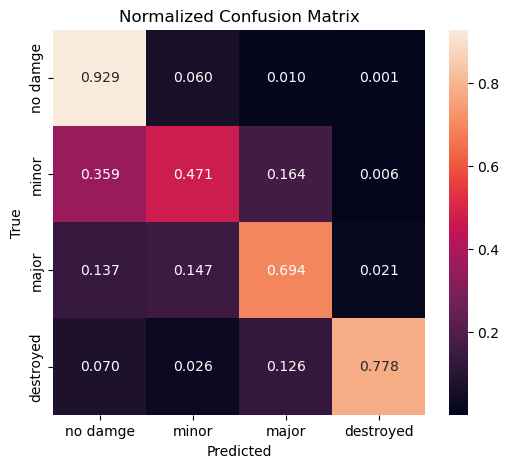

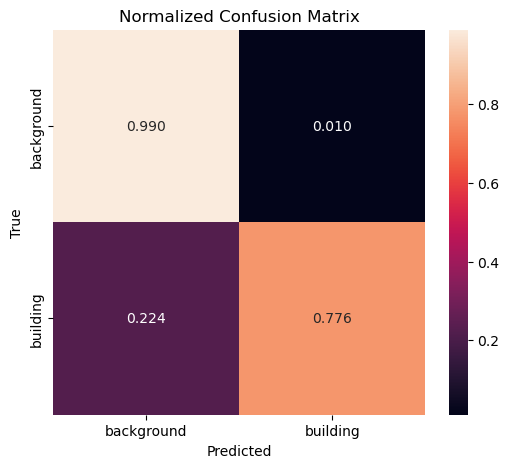

In [11]:
import evaluation
evaluator = evaluation.XView2Evaluator(device=device)

model.eval()
with torch.no_grad():
    for images in dataset:
        cuda_image = images["image"].unsqueeze(0).to(device, non_blocking=True)
        y_true = images["post_mask"].to(device)

        with torch.amp.autocast(device_type="cuda"):
            building_out, damage_out = model(cuda_image)

        _, d_pred = get_predictions(building_out, damage_out)

        # print("GT unique:", torch.unique(y_true))
        # print("Pred unique:", torch.unique(d_pred))

        # print("GT buildings:", (y_true > 0).sum().item())
        # print("Pred buildings:", (d_pred > 0).sum().item())

        # print("Overlap (TP):", ((y_true > 0) & (d_pred > 0)).sum().item())

        evaluator.update(y_true, d_pred)

        # optional cleanup
        del cuda_image, building_out, damage_out, d_pred

# Final metrics
metrics = evaluator.compute()
print(metrics)
evaluation.plot_confusion(metrics['damage_cm'], labels=['no damge', 'minor', 'major', 'destroyed'])
evaluation.plot_confusion(metrics['building_cm'], labels=['background', 'building'])